In [1]:
# -*- coding: utf-8 -*-

01_non_personalized.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1GRKq9HwfiT91QH1EgNq9My6Th4CV54Qv

# Non-Personalized Recommender Systems

In this notebook, we build and evaluate three non-personalized recommendation approaches using the MovieLens dataset:

1. Average Rating Recommender
2. Popularity-Based Recommender
3. Weighted Rating Recommender

These methods recommend the same items to every user and provide strong baseline models for comparison with more advanced recommenders.

Contributors: Juan Múñoz, Santiago Llorca

# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# LOAD THE DATA

In [3]:
try:
    ratings = pd.read_csv("ml-latest-small/ratings.csv")
    movies = pd.read_csv("ml-latest-small/movies.csv")
except FileNotFoundError:
    ratings = pd.read_csv("ratings.csv")
    movies = pd.read_csv("movies.csv")

ratings.head()

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


# DATASET OVERVIEW

In [4]:
n_users = ratings["userId"].nunique()
n_items = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_items)

print(f"Number of users: {n_users}")
print(f"Number of movies: {n_items}")
print(f"Number of ratings: {n_ratings}")
print(f"Sparsity: {sparsity:.2%}")

Number of users: 610
Number of movies: 9724
Number of ratings: 100836
Sparsity: 98.30%


# BASIC EDA

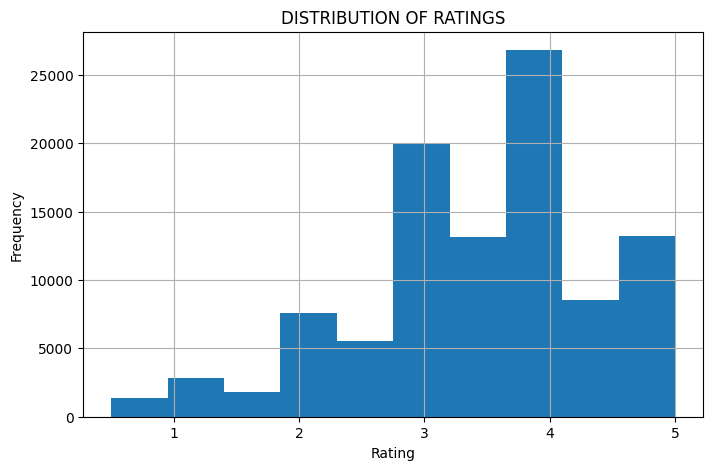

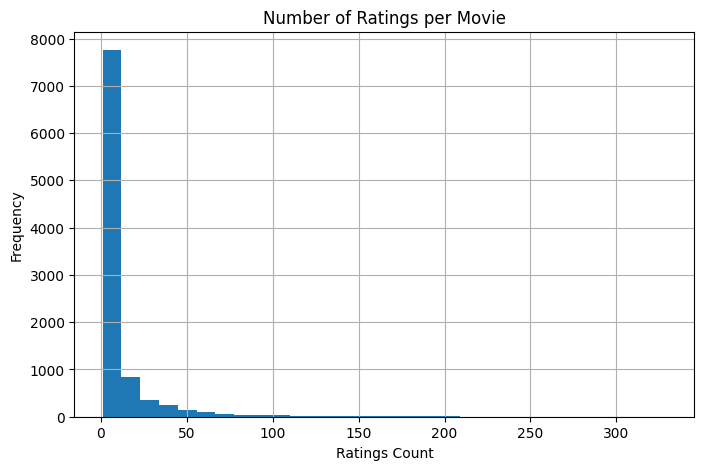

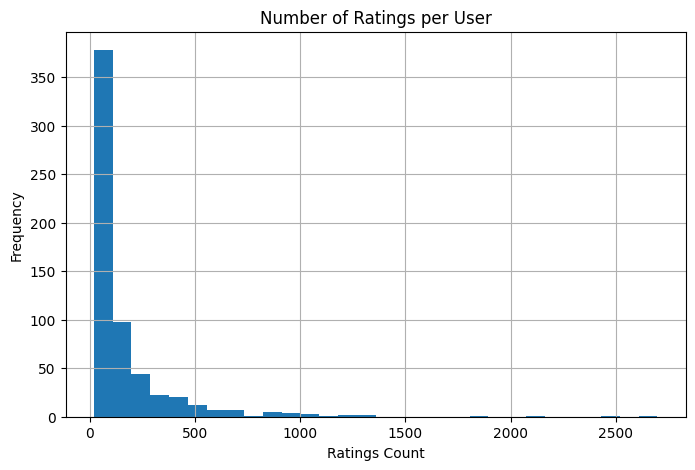

In [5]:
plt.figure(figsize=(8, 5))
ratings["rating"].hist(bins=10)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("DISTRIBUTION OF RATINGS")
plt.show()

ratings_per_movie = ratings.groupby("movieId")["rating"].count()

plt.figure(figsize=(8, 5))
ratings_per_movie.hist(bins=30)
plt.title("Number of Ratings per Movie")
plt.xlabel("Ratings Count")
plt.ylabel("Frequency")
plt.show()

ratings_per_user = ratings.groupby("userId")["rating"].count()

plt.figure(figsize=(8, 5))
ratings_per_user.hist(bins=30)
plt.title("Number of Ratings per User")
plt.xlabel("Ratings Count")
plt.ylabel("Frequency")
plt.show()

The dataset shows a long-tail pattern: a small number of movies receive many ratings, while most movies receive only a few. The same happens with users, since some users are much more active than others.

# MOVIE STATISTICS TABLE

## TRAIN / TEST SPLIT

We split ratings by time (80/20) to simulate a realistic evaluation scenario. The movie statistics table is computed on training data only to avoid data leakage.

In [6]:
# Temporal train/test split (80/20)
ratings_sorted = ratings.sort_values("timestamp")
cutoff = int(len(ratings_sorted) * 0.8)
train = ratings_sorted.iloc[:cutoff].copy()
test = ratings_sorted.iloc[cutoff:].copy()

print(f"Train size: {len(train)}")
print(f"Test size:  {len(test)}")

movie_stats = train.groupby("movieId").agg(
    avg_rating=("rating", "mean"),
    num_ratings=("rating", "count")
).reset_index()

movie_stats = movie_stats.merge(movies[["movieId", "title"]], on="movieId")
movie_stats.head()

Train size: 80668
Test size:  20168


,movieId,avg_rating,num_ratings,title
0,1,3.923913,184,Toy Story (1995)
1,2,3.400000,95,Jumanji (1995)
2,3,3.294118,51,Grumpier Old Men (1995)
3,4,2.357143,7,Waiting to Exhale (1995)
4,5,3.063830,47,Father of the Bride Part II (1995)


# RECOMMENDER 1: AVERAGE RATING

In [7]:
top10_avg = movie_stats.sort_values("avg_rating", ascending=False).head(10)
top10_avg[["title", "avg_rating", "num_ratings"]]

,title,avg_rating,num_ratings
3865,Satin Rouge (2002),5.0,1
3217,Dr. Goldfoot and the Bikini Machine (1965),5.0,1
5603,Palindromes (2004),5.0,1
4282,Animals are Beautiful People (1974),5.0,1
1874,"Ballad of Narayama, The (Narayama bushiko) (1983)",5.0,1
3255,More (1998),5.0,1
7410,Bill Hicks: Revelations (1993),5.0,1
7409,Mud (2012),5.0,1
2310,Babes in Toyland (1934),5.0,1
3245,"Way of the Dragon, The (a.k.a. Return of the D...",5.0,1


This recommender ranks movies by their average rating only.

Its main limitation is that movies with very few ratings can appear at the top, even if the score is not reliable.

# RECOMMENDER 2: POPULARITY

In [8]:
top10_pop = movie_stats.sort_values("num_ratings", ascending=False).head(10)
top10_pop[["title", "avg_rating", "num_ratings"]]

,title,avg_rating,num_ratings
314,Forrest Gump (1994),4.166667,267
257,Pulp Fiction (1994),4.189394,264
277,"Shawshank Redemption, The (1994)",4.423828,256
508,"Silence of the Lambs, The (1991)",4.202128,235
1924,"Matrix, The (1999)",4.214612,219
416,Jurassic Park (1993),3.786697,218
97,Braveheart (1995),4.058962,212
224,Star Wars: Episode IV - A New Hope (1977),4.264563,206
505,Terminator 2: Judgment Day (1991),3.970000,200
459,Schindler's List (1993),4.228723,188


This recommender ranks movies by the number of ratings they received.

It captures engagement and popularity, but it does not consider whether users actually liked the movie.

# RECOMMENDER 3: WEIGHTED RATING

In [9]:
C = train["rating"].mean()   # FIX: use train only to avoid data leakage
m = movie_stats["num_ratings"].quantile(0.75)

def imdb_weighted_rating(row, m, C):
    v = row["num_ratings"]
    R = row["avg_rating"]
    W = (v / (v + m)) * R + (m / (v + m)) * C
    return W

movie_stats["weighted_rating"] = movie_stats.apply(
    imdb_weighted_rating, axis=1, args=(m, C)
)

top10_weighted = movie_stats.sort_values("weighted_rating", ascending=False).head(10)
top10_weighted[["title", "avg_rating", "num_ratings", "weighted_rating"]]

,title,avg_rating,num_ratings,weighted_rating
277,"Shawshank Redemption, The (1994)",4.423828,256,4.392741
656,"Godfather, The (1972)",4.309816,163,4.267886
600,Dr. Strangelove or: How I Learned to Stop Worr...,4.347561,82,4.264575
2207,Fight Club (1999),4.272455,167,4.233388
224,Star Wars: Episode IV - A New Hope (1977),4.264563,206,4.232913
691,Casablanca (1942),4.302198,91,4.230763
893,"Princess Bride, The (1987)",4.275424,118,4.221073
46,"Usual Suspects, The (1995)",4.255682,176,4.219331
836,"Streetcar Named Desire, A (1951)",4.552632,19,4.217011
3566,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",4.281250,96,4.215013


The weighted rating recommender balances quality and popularity.

It reduces the effect of movies with very few ratings by shrinking their score toward the global average. This produces more reliable rankings than simple average rating.

# COMPARE THE THREE TOP-10

In [10]:
print("Top 10 by Average Rating")
display(top10_avg[["title", "avg_rating", "num_ratings"]])

print("Top 10 by Popularity")
display(top10_pop[["title", "avg_rating", "num_ratings"]])

print("Top 10 by Weighted Rating")
display(top10_weighted[["title", "avg_rating", "num_ratings", "weighted_rating"]])

Top 10 by Average Rating


,title,avg_rating,num_ratings
3865,Satin Rouge (2002),5.0,1
3217,Dr. Goldfoot and the Bikini Machine (1965),5.0,1
5603,Palindromes (2004),5.0,1
4282,Animals are Beautiful People (1974),5.0,1
1874,"Ballad of Narayama, The (Narayama bushiko) (1983)",5.0,1
3255,More (1998),5.0,1
7410,Bill Hicks: Revelations (1993),5.0,1
7409,Mud (2012),5.0,1
2310,Babes in Toyland (1934),5.0,1
3245,"Way of the Dragon, The (a.k.a. Return of the D...",5.0,1


Top 10 by Popularity


,title,avg_rating,num_ratings
314,Forrest Gump (1994),4.166667,267
257,Pulp Fiction (1994),4.189394,264
277,"Shawshank Redemption, The (1994)",4.423828,256
508,"Silence of the Lambs, The (1991)",4.202128,235
1924,"Matrix, The (1999)",4.214612,219
416,Jurassic Park (1993),3.786697,218
97,Braveheart (1995),4.058962,212
224,Star Wars: Episode IV - A New Hope (1977),4.264563,206
505,Terminator 2: Judgment Day (1991),3.970000,200
459,Schindler's List (1993),4.228723,188


Top 10 by Weighted Rating


,title,avg_rating,num_ratings,weighted_rating
277,"Shawshank Redemption, The (1994)",4.423828,256,4.392741
656,"Godfather, The (1972)",4.309816,163,4.267886
600,Dr. Strangelove or: How I Learned to Stop Worr...,4.347561,82,4.264575
2207,Fight Club (1999),4.272455,167,4.233388
224,Star Wars: Episode IV - A New Hope (1977),4.264563,206,4.232913
691,Casablanca (1942),4.302198,91,4.230763
893,"Princess Bride, The (1987)",4.275424,118,4.221073
46,"Usual Suspects, The (1995)",4.255682,176,4.219331
836,"Streetcar Named Desire, A (1951)",4.552632,19,4.217011
3566,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",4.281250,96,4.215013


The three recommenders produce different ranking logics:

- Average rating favors movies with the highest mean score, even if they have very few ratings.
- Popularity favors movies with the largest number of ratings, regardless of quality.
- Weighted rating provides a compromise between both signals.

Among the three, weighted rating is usually the strongest non-personalized baseline because it balances reliability and popularity.

# Conclusion

In this notebook, we implemented three non-personalized recommenders.

The average rating one is simple but unreliable for movies with few ratings. The popularity one captures engagement but ignores quality. The weighted rating combines both, making it the most balanced of the three.

These approaches are useful because they are simple and work well when there is no user data. The downside is that they recommend the same thing to everyone, so more advanced methods like collaborative filtering are needed for personalized suggestions.

## WEIGHTED RATING PREDICTIONS ON TEST SET

We generate predictions for the test set using the weighted rating. Since this is a non-personalized model, every user receives the same predicted rating for a given movie (its weighted rating). We export the results so the evaluation notebook can compute metrics alongside the other recommenders.

In [11]:
# Map weighted rating back to test rows
weighted_map = movie_stats.set_index("movieId")["weighted_rating"]
global_mean_np = train["rating"].mean()

test["pred_weighted"] = test["movieId"].map(weighted_map).fillna(global_mean_np)

# Clip to valid rating range
test["pred_weighted"] = test["pred_weighted"].clip(0.5, 5.0)

# Export predictions for Notebook 5

# 1. Rebuild the same temporal split
ratings_eval = ratings.sort_values("timestamp").copy()
cutoff = int(len(ratings_eval) * 0.8)

train_eval = ratings_eval.iloc[:cutoff].copy()
test_eval = ratings_eval.iloc[cutoff:].copy()

# 2. Compute weighted non-personalized score using train only
movie_stats_eval = train_eval.groupby("movieId").agg(
    avg_rating=("rating", "mean"),
    num_ratings=("rating", "count")
).reset_index()

C_eval = train_eval["rating"].mean()
m_eval = movie_stats_eval["num_ratings"].quantile(0.75)

movie_stats_eval["score_non_personalized"] = (
    (movie_stats_eval["num_ratings"] / (movie_stats_eval["num_ratings"] + m_eval)) * movie_stats_eval["avg_rating"]
    + (m_eval / (movie_stats_eval["num_ratings"] + m_eval)) * C_eval
)

weighted_scores_eval = movie_stats_eval.set_index("movieId")["score_non_personalized"]

# 3. Create prediction dataframe on the test set
pred_np = test_eval[["userId", "movieId", "rating"]].copy()
pred_np["score_non_personalized"] = pred_np["movieId"].map(weighted_scores_eval).fillna(C_eval)

# 4. Export CSV
# Rename score column to predicted_rating for consistency with other notebooks
# The weighted rating IS our best rating prediction for non-personalized
pred_np = pred_np.rename(columns={"score_non_personalized": "predicted_rating_non_personalized"})

# Keep score_non_personalized as an alias so notebook 05 ranking metrics still work
pred_np["score_non_personalized"] = pred_np["predicted_rating_non_personalized"]

pred_np.to_csv("predictions_non_personalized.csv", index=False)

print(pred_np.shape)
pred_np.head()

(20168, 5)


,userId,movieId,rating,predicted_rating_non_personalized,score_non_personalized
79691,495,72998,5.0,3.662521,3.662521
79564,495,2762,4.5,3.866102,3.866102
79601,495,4993,0.5,4.093642,4.093642
79709,495,89492,5.0,3.632456,3.632456
79551,495,2028,4.5,4.130230,4.130230
